In [166]:
# 3. ZADATAK: Neuronske mreže

# Kontekst (Po uzoru na JUN1 i SEP2): Data je datoteka mobile_prices.csv koja sadrži podatke o karakteristikama mobilnih telefona.
# Cilj je napraviti klasifikacioni model koji predviđa u koju od 4 cenovne kategorije spada telefon na osnovu njegovih specifikacija.

# Zahtevi:
# Učitati skup podataka i ispisati prvih 5 redova pomoću biblioteke pandas.
# Izbaciti kolonu Brand (ako postoji) i ukloniti sve redove sa nedostajućim vrednostima.
# Kodirati ciljnu promenljivu price_range u one-hot format pomoću Keras-a.
# Podeliti podatke na skup za treniranje (80%) i testiranje (20%).
# Standardizovati (ili normalizovati) ulazne podatke.
# Napraviti potpuno povezanu neuronsku mrežu sa sledećim slojevima:
# Ulazni sloj.
# Gusto povezan sloj sa 32 neurona i relu aktivacijom.
# Sloj za regularizaciju (Dropout) sa stopom 0.2 (kako bi se sprečilo preprilagođavanje).
# Izlazni sloj sa brojem neurona jednakim broju klasa i odgovarajućom aktivacionom funkcijom za višeklasnu klasifikaciju.
# Kompilirati model sa Adam optimizatorom (isprobati stope učenja learning_rate iz skupa [0.01, 0.001] preko validacionog skupa koji iznosi 20% trening skupa).
# Istrenirati finalni model sa boljom stopom učenja u 50 epoha.
# Nacrtati grafik krive gubitka (loss) na trening i validacionom skupu kroz epohe.
# Evaluirati model na test skupu i prikazati tačnost (accuracy) modela.

In [167]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [168]:
tf.keras.utils.set_random_seed(42)

In [169]:
dataset = pd.read_csv("mobile_prices.csv")
dataset.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [170]:
if "Brand" in dataset.columns:
  dataset = dataset.drop(columns = ["Brand"])

In [171]:
labels = dataset.pop("price_range")
num_of_classes = len(labels.unique())

In [172]:
labels_cat = tf.keras.utils.to_categorical(labels, num_classes = num_of_classes)
labels_cat

array([[0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 0., 1.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.]])

In [173]:
train_dataset, test_dataset, train_labels, test_labels = train_test_split(dataset, labels_cat, test_size = 0.2, random_state = 42, stratify = labels)
train_dataset, validation_dataset, train_labels, validation_labels = train_test_split(train_dataset, train_labels, test_size = 0.2, random_state = 42, stratify = np.argmax(train_labels, axis = 1))

In [174]:
train_stats = train_dataset.describe().transpose()

In [175]:
def norm(X):
  return (X - train_stats["mean"]) / train_stats["std"]

In [176]:
normed_train_dataset = norm(train_dataset).astype("float32")
normed_validation_dataset = norm(validation_dataset).astype("float32")
normed_test_dataset = norm(test_dataset).astype("float32")

In [177]:
num_of_atributtes = normed_train_dataset.shape[1]

In [178]:
def build_model(learning_rate):
  model = tf.keras.Sequential([
      tf.keras.layers.InputLayer(input_shape = (num_of_atributtes,)),
      tf.keras.layers.Dense(32, activation = 'relu'),
      tf.keras.layers.Dropout(0.2),
      tf.keras.layers.Dense(num_of_classes, activation = 'softmax')
  ]);

  model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate), loss = tf.keras.losses.CategoricalCrossentropy(), metrics = ["accuracy"])

  return model

In [179]:
learning_rates = [0.01, 0.001]

validation_results = []
for learning_rate in learning_rates:
  tf.keras.backend.clear_session()
  tf.keras.utils.set_random_seed(42)

  model = build_model(learning_rate)

  history = model.fit(normed_train_dataset, train_labels, epochs = 50, validation_data = (normed_validation_dataset, validation_labels), verbose = 0)

  best_validation_result = max(history.history["val_accuracy"])

  validation_results.append({
      "best_validation_result": best_validation_result,
      "learning_rate": learning_rate
  })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [180]:
validation_results

[{'best_validation_result': 0.96875, 'learning_rate': 0.01},
 {'best_validation_result': 0.9375, 'learning_rate': 0.001}]

In [181]:
result = sorted(validation_results, key = lambda result: (-result["best_validation_result"], result["learning_rate"]))[0]
best_learning_rate = result["learning_rate"]

In [182]:
# train_dataset_full = pd.concat([train_dataset, validation_dataset])
# train_labels_full = np.concatenate([train_labels, validation_labels])

In [183]:
# train_stats = train_dataset_full.describe().transpose()

In [184]:
# normed_train_data_full = norm(train_dataset_full).astype("float32")
# normed_test_data = norm(test_dataset).astype("float32")

In [185]:
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

model = build_model(learning_rate)
history = model.fit(normed_train_dataset, train_labels, epochs = 50, validation_data = (normed_validation_dataset, validation_labels), verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


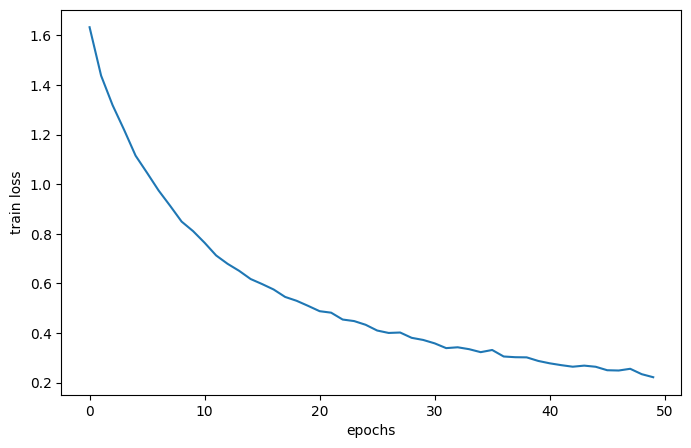

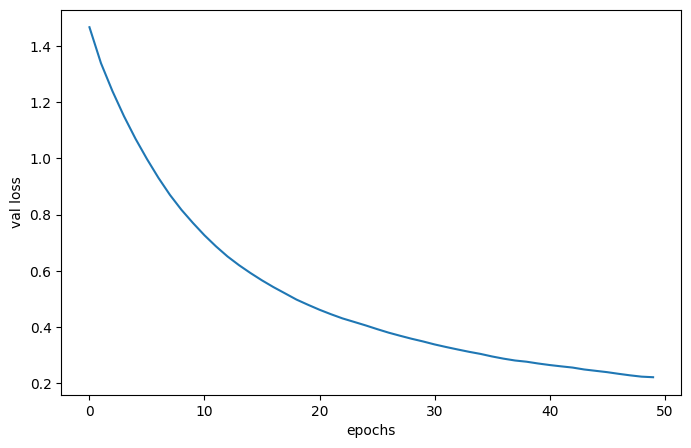

In [186]:
plt.figure(figsize = (8, 5))
plt.plot(history.epoch, history.history["loss"])
plt.xlabel("epochs")
plt.ylabel("train loss")
plt.show()

plt.figure(figsize = (8, 5))
plt.plot(history.epoch, history.history["val_loss"])
plt.ylabel("val loss")
plt.xlabel("epochs")
plt.show()

In [188]:
_, test_acc = model.evaluate(normed_test_data, test_labels, verbose = 0)
test_acc

0.949999988079071